In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
import random
from tqdm.autonotebook import tqdm
import seaborn as sns
from envs import IGTEnv
from basal_ganglia import train
import pickle

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_10111/3918124140.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


In [2]:
# Hyperparameters
TRAILS = 100
EPOCHS = 1
NUM_BINS = 5
LR = 0.1
NUM_ARMS = 4
SCALING_FACTOR = 100
REW_STD = 0
LOSS_STD = 0
cases = ['PD', 'std DBS', 'Open loop low amp', 'Open loop high amp', 'closed loop']
dbs_conds=[None, 'standard_dbs', 'open_loop_low', 'open_loop_high', 'closed_loop'] # for running train loop
del_lim = [0.2, 0.8, 1]
Results_dict = {key: {value: [] for value in del_lim} for key in cases}

In [ ]:
for i in range(len(cases)):
    case = cases[i]
    dbs_cond = dbs_conds[i]
    for j in range(len(del_lim)):
        delta = del_lim[j]
        print(f"Running case: {case}, dbs_cond: {dbs_cond}, delta: {delta}")
        env = IGTEnv(mean_reward=np.array([100, 100, 50, 50]) / SCALING_FACTOR,
                         std_reward=np.array([REW_STD, REW_STD, REW_STD, REW_STD]) / SCALING_FACTOR,
                         mean_loss=np.array([-250, -1250, -50, -250]) / SCALING_FACTOR,
                         std_loss=np.array([LOSS_STD, LOSS_STD, LOSS_STD, LOSS_STD]) / SCALING_FACTOR)
            
        _, _, avg_counts, _, _, _ = train(env, 
                                            trails=TRAILS, 
                                            epochs=EPOCHS, 
                                            lr=LR, 
                                            bins=NUM_BINS, 
                                            STN_data='rossler', 
                                            dbs_cond=dbs_cond,
                                            d1_amp=0.5, 
                                            d2_amp=0.01, 
                                            gpi_threshold=0.15, 
                                            max_gpi_iters=50, 
                                            del_lim=delta, 
                                            train_IP=False, 
                                            del_med=None, 
                                            printing=False, 
                                            gpi_mean=1, 
                                            ep_0= 0.1, 
                                            alpha_ep=0.0, 
                                            eta_ep=0.1, 
                                            baseline_ep=0.0, 
                                            ep_lim=0.1)
        
        C_picks = avg_counts[2]
        D_picks = avg_counts[3]
        A_picks = avg_counts[0]
        B_picks = avg_counts[1]
        
        igt_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim=0).squeeze().numpy()
        igt_error = (torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim=0) / 
                        torch.sqrt(torch.tensor(EPOCHS, dtype=torch.float32))).squeeze().numpy()
            
        Results_dict[case][delta] = igt_score[-1]
        

In [4]:
igt_scores = {case: [] for case in cases}

for case in cases:
    igt_mon = []
    for delta in del_lim:
        igt_mon.append(Results_dict[case][delta])
    igt_scores[case] = igt_mon

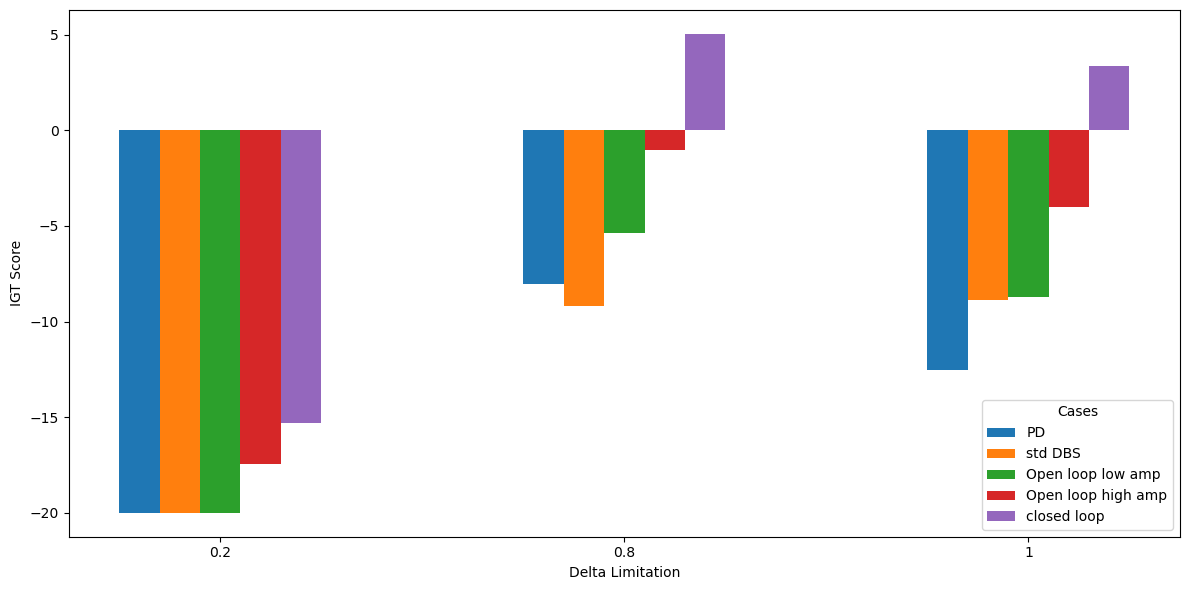

In [5]:
# bar plot for last bin accuracies one after the other for all 5 cases where x axis is del_lim and y axis is accuracy percentage
x = np.arange(len(del_lim))  # the label locations
width = 0.1 # the width of the bars
fig, ax = plt.subplots(figsize=(12, 6))
for i, case in enumerate(cases):
    ax.bar(x + i * width, igt_scores[case], width, label=case)
ax.set_xlabel('Delta Limitation')
ax.set_ylabel('IGT Score')
ax.set_xticks(x + width * (len(cases) - 1) /2)
ax.set_xticklabels(del_lim)
ax.legend(title='Cases')
plt.tight_layout()
